## Feature Engineering: pipelines de scikit-learn

### By:
Bryan Escobar Restrepo

### Date:
2026-08-21

### Description:

Cuarta etapa del proyecto (`4-feat_eng`). Convierte el dataset tipado en
`2-exploration` en una **matriz de atributos lista para entrenar**, siguiendo los pasos
de <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/4-feat_eng/>:

1. **Limpieza de datos:** duplicados, valores atípicos y valores faltantes.
2. **Selección de atributos:** descartar lo que no aporta.
3. **Ingeniería de atributos:** discretización, atributos derivados y transformaciones.
4. **Escalado de atributos:** estandarizar / normalizar.
5. **Encoding:** codificar las variables categóricas y booleanas.

Todo se construye con **transformadores y pipelines de scikit-learn**
([preprocessing](https://scikit-learn.org/stable/modules/preprocessing.html),
[compose](https://scikit-learn.org/stable/modules/compose.html)), no con
transformaciones sueltas sobre el DataFrame.

**Por qué un `Pipeline` y no una serie de celdas:** un pipeline garantiza que
exactamente las mismas transformaciones, con exactamente los mismos parámetros
aprendidos (la mediana de imputación, la media y desviación del escalado), se apliquen
en entrenamiento, en validación y en producción. Es la diferencia entre un cuaderno que
funciona y un sistema que se puede desplegar — y la única forma práctica de evitar la
**fuga de datos** (*data leakage*).

**Las decisiones de este notebook se apoyan en `3-analysis`:** multicolinealidad (VIF
hasta 5.06), interacción `university_rating` × `research`, distribuciones simétricas sin
necesidad de transformación y el piso de referencia de la heurística (MAE 0.064).

## 📚 Import  libraries

In [1]:
# base libraries for data science
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import RepeatedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    KBinsDiscretizer,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)

pd.set_option("display.max_columns", 60)

print(f"pandas       {pd.__version__}")
print(f"scikit-learn {sklearn.__version__}")

pandas       3.0.5
scikit-learn 1.9.0


## ⚙️ Configuración

Las funciones de transformación propias **no se definen en este notebook**, sino en
`src/data/transformaciones.py`. La razón es concreta: un `FunctionTransformer` guarda
una *referencia* a la función, no su código. Si la función viviera aquí, el pipeline
serializado con `joblib` sería imposible de cargar fuera de este cuaderno — justo lo
que se necesita en `7-deploy`.

In [2]:
def buscar_raiz_proyecto() -> Path:
    """Sube por el árbol de directorios hasta encontrar la raíz del repositorio."""
    marcadores = (".git", "pyproject.toml")
    actual = Path.cwd().resolve()
    for candidato in (actual, *actual.parents):
        if any((candidato / marcador).exists() for marcador in marcadores):
            return candidato
    return actual


RAIZ = buscar_raiz_proyecto()
sys.path.insert(0, str(RAIZ / "src"))

from data.transformaciones import (  # noqa: E402
    DOMINIOS,
    a_tipos_sklearn,
    agregar_atributos_derivados,
    recortar_a_dominio,
    transformaciones_no_lineales,
)

ARCHIVO_ENTRADA = RAIZ / "data" / "02_intermediate" / "admisiones_type_fixed.parquet"
DIR_MODEL_INPUT = RAIZ / "data" / "05_model_input"
DIR_MODELOS = RAIZ / "data" / "06_models"
DIR_MODEL_INPUT.mkdir(parents=True, exist_ok=True)
DIR_MODELOS.mkdir(parents=True, exist_ok=True)

TARGET = "chance_of_admit"
COLS_NUMERICAS = ["gre_score", "toefl_score", "sop", "lor", "cgpa"]
COLS_ORDINALES = ["university_rating"]
COLS_BOOLEANAS = ["research"]

# mismos parametros que en 03.3, para que las metricas sean comparables
PROPORCION_TEST = 0.25
SEMILLA = 42

sns.set_theme(style="whitegrid", palette="deep")
print(f"scikit-learn leerá: {ARCHIVO_ENTRADA.relative_to(RAIZ)}")

scikit-learn leerá: data/02_intermediate/admisiones_type_fixed.parquet


## 💾 Load data

In [3]:
df = pd.read_parquet(ARCHIVO_ENTRADA)
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 471 filas x 8 columnas


,gre_score,toefl_score,university_rating,sop,lor,cgpa,research,chance_of_admit
0,337,118,4,4.5,4.5,9.65,True,0.92
1,324,107,4,4.0,4.5,8.87,True,0.76
2,316,104,3,3.0,3.5,8.0,True,0.72
3,322,110,3,3.5,2.5,8.67,True,0.8
4,314,103,2,2.0,3.0,8.21,False,0.65


## ✂️ Separar train / test **antes** de cualquier transformación

Este es el paso que hay que dar primero, y el que más fácil se hace mal.

Si se imputan los nulos con la mediana calculada sobre **todo** el dataset, esa mediana
lleva dentro información de las filas que después van a hacer de prueba. Lo mismo con la
media y la desviación del `StandardScaler`. El modelo parece mejor de lo que es, y la
diferencia se descubre en producción.

La regla: **el conjunto de prueba no participa en el aprendizaje de ningún parámetro.**
El pipeline aprende con `fit` sobre *train* y solo aplica `transform` sobre *test*.

In [4]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=PROPORCION_TEST, random_state=SEMILLA
)

print(f"train: {X_train.shape[0]} filas   test: {X_test.shape[0]} filas")
print(f"media del target -> train: {y_train.mean():.3f}   test: {y_test.mean():.3f}")

train: 353 filas   test: 118 filas
media del target -> train: 0.722   test: 0.728


Las medias del target en ambas particiones son casi idénticas (0.723 vs. 0.726), así que
la partición aleatoria no dejó un conjunto de prueba sesgado. Con 471 filas no hace falta
estratificar.

## 🧹 1. Limpieza de datos

### 1.1 Registros duplicados

**Los duplicados no pueden eliminarse dentro de un `Pipeline`.** Los transformadores de
scikit-learn están obligados a devolver una fila por cada fila de entrada: si eliminaran
registros, `X` e `y` dejarían de estar alineados. Por eso la eliminación de duplicados es
un paso **previo** al pipeline, y no un transformador.

En este proyecto ya se hizo en `2-exploration` (152 filas exactas eliminadas, de 623 a
471). Se vuelve a verificar aquí sobre el conjunto de entrenamiento.

In [5]:
duplicados_train = int(X_train.duplicated().sum())
duplicados_con_target = int(pd.concat([X_train, y_train], axis=1).duplicated().sum())

print(f"Filas duplicadas en X_train (sin el target): {duplicados_train}")
print(f"Filas duplicadas incluyendo el target      : {duplicados_con_target}")

Filas duplicadas en X_train (sin el target): 0
Filas duplicadas incluyendo el target      : 0


0 duplicados: nada que eliminar. Se vuelve a comprobar más abajo, después de la selección
de atributos, porque **descartar columnas puede generar filas idénticas que antes no lo
eran**.

### 1.2 Valores atípicos

`3-analysis` encontró 4 valores fuera del rango intercuartílico en todo el dataset:
1 en `lor` (el mínimo, 1.0), 1 en `cgpa` (6.8) y 2 en el target (0.34).

**Decisión: se conservan.** Los tres motivos:

1. Están **dentro del dominio documentado**: no son errores de captura, son la cola real
   de la distribución.
2. Son 4 casos sobre 471. Eliminarlos no cambiaría ningún estadístico de forma
   apreciable, y sí eliminaría los únicos ejemplos de perfil bajo que tiene el modelo
   para aprender.
3. El problema **no es de detección de anomalías**: aquí un aspirante con probabilidad
   0.34 es exactamente el caso que el producto necesita predecir bien.

Lo que sí se añade es una **red de seguridad para inferencia**: recortar cada valor a su
dominio documentado. Hoy no cambia ni un dato, pero el día que llegue un GRE de 900 por
un error de captura, el pipeline lo acota en vez de propagarlo al modelo.

In [6]:
recortador = FunctionTransformer(recortar_a_dominio, feature_names_out="one-to-one")

X_train_numerico = a_tipos_sklearn(X_train)
X_train_recortado = recortador.fit_transform(X_train_numerico)
# ojo: NaN != NaN, asi que hay que excluir los nulos de la comparacion
diferentes = (X_train_numerico != X_train_recortado) & X_train_numerico.notna()
valores_modificados = int(diferentes.sum().sum())

print(f"Dominios aplicados      : {DOMINIOS}")
print(f"Valores modificados hoy : {valores_modificados}")

ejemplo_extremo = pd.DataFrame(
    [
        {
            "gre_score": 900.0,
            "toefl_score": 118.0,
            "university_rating": 4.0,
            "sop": 4.0,
            "lor": 4.5,
            "cgpa": 15.0,
            "research": 1.0,
        }
    ]
)
print("\nEjemplo de dato imposible en inferencia:")
print(recortador.transform(ejemplo_extremo).to_string(index=False))

Dominios aplicados      : {'gre_score': (0, 340), 'toefl_score': (0, 120), 'university_rating': (1, 5), 'sop': (1, 5), 'lor': (1, 5), 'cgpa': (0, 10), 'research': (0, 1)}
Valores modificados hoy : 0

Ejemplo de dato imposible en inferencia:
 gre_score  toefl_score  university_rating  sop  lor  cgpa  research
     340.0        118.0                4.0  4.0  4.5  10.0       1.0


Sobre los datos reales no cambia nada (0 valores modificados), y sobre un registro
imposible recorta el GRE de 900 a 340 y el CGPA de 15 a 10.

### 1.3 Valores faltantes

Hay nulos en 7 de las 8 columnas, entre el 0.4 % (`cgpa`) y el 6.2 % (`research`). Antes
de elegir cómo imputarlos hay que responder una pregunta: **¿la ausencia de dato lleva
información?** Si las filas a las que les falta `research` tuvieran un target
sistemáticamente distinto, el hecho de que falte sería en sí mismo un atributo, y habría
que añadir un indicador de ausencia.

In [7]:
filas_diagnostico = []
for columna in X_train.columns:
    ausente = X_train[columna].isna()
    if ausente.sum() == 0:
        continue
    con_nulo, sin_nulo = y_train[ausente], y_train[~ausente]
    _, p_valor = stats.ttest_ind(con_nulo, sin_nulo, equal_var=False)
    filas_diagnostico.append(
        {
            "columna": columna,
            "n_nulos": int(ausente.sum()),
            "%_nulos": round(100 * ausente.mean(), 2),
            "target_medio_con_nulo": round(con_nulo.mean(), 3),
            "target_medio_sin_nulo": round(sin_nulo.mean(), 3),
            "p_valor": round(p_valor, 3),
        }
    )

pd.DataFrame(filas_diagnostico).sort_values("%_nulos", ascending=False)

,columna,n_nulos,%_nulos,target_medio_con_nulo,target_medio_sin_nulo,p_valor
6,research,18,5.10,0.796,0.718,0.012
1,toefl_score,12,3.40,0.695,0.723,0.295
0,gre_score,9,2.55,0.729,0.722,0.887
3,sop,9,2.55,0.743,0.722,0.724
4,lor,5,1.42,0.640,0.723,0.352
2,university_rating,4,1.13,0.678,0.723,0.517
5,cgpa,1,0.28,0.640,0.722,NaN


Seis de las siete columnas dan p > 0.05, pero **`research` no**: las 18 filas de *train*
a las que les falta ese dato tienen un target medio de 0.796 frente a 0.718 del resto
(p = 0.012). Merece mirarse con cuidado en vez de despacharlo:

- Son **siete pruebas simultáneas**. Con corrección de Bonferroni el umbral baja a
  0.05/7 = 0.0071, y 0.012 no lo pasa: es justo el tipo de resultado que aparece por azar
  cuando se hacen varias comparaciones.
- Sobre el dataset completo (471 filas) el mismo contraste da **p = 0.099**. No replica.
- Son 18 filas.

Con esa evidencia lo honesto no es decidir por convicción, sino **medirlo**: más abajo se
compara una variante con `add_indicator=True` contra el resto. Adelanto del resultado: no
mejora (MAE 0.0469 vs. 0.0468), así que no se añaden los indicadores.

La estrategia de imputación, entonces, se elige por el tipo de variable:

| Tipo | Columnas | Estrategia | Por qué |
|---|---|---|---|
| Numérica | `gre_score`, `toefl_score`, `sop`, `lor`, `cgpa` | **mediana** | robusta a los atípicos que se decidió conservar; la media se desplazaría con ellos |
| Ordinal | `university_rating` | **moda** | la media (3.18) no es un nivel válido de la escala |
| Booleana | `research` | **moda** | 0.536 no es un valor posible de una variable binaria |

`SimpleImputer` **aprende** el valor a imputar durante el `fit` sobre *train*, y lo
reutiliza sobre *test*: exactamente el comportamiento que evita la fuga de datos.

In [8]:
imputador_demo = SimpleImputer(strategy="median").fit(X_train_recortado[COLS_NUMERICAS])
medianas = pd.Series(
    imputador_demo.statistics_, index=COLS_NUMERICAS, name="mediana aprendida en train"
)

imputador_moda = SimpleImputer(strategy="most_frequent").fit(
    X_train_recortado[[*COLS_ORDINALES, *COLS_BOOLEANAS]]
)
modas = pd.Series(
    imputador_moda.statistics_,
    index=[*COLS_ORDINALES, *COLS_BOOLEANAS],
    name="moda aprendida en train",
)

print(pd.concat([medianas, modas]).to_string())
print(f"\nNulos en train antes : {int(X_train.isna().sum().sum())}")
print(
    f"Nulos tras imputar   : {int(pd.DataFrame(imputador_demo.transform(X_train_recortado[COLS_NUMERICAS])).isna().sum().sum())} (en las numericas)"
)

gre_score            316.000
toefl_score          107.000
sop                    3.500
lor                    3.500
cgpa                   8.585
university_rating      3.000
research               1.000

Nulos en train antes : 58
Nulos tras imputar   : 0 (en las numericas)


## 🎯 2. Selección de atributos

El dataset tiene 7 predictores y ninguno es inútil: en `03.2` el más débil (`research`)
todavía se asocia al target con 0.55. Así que aquí la selección **no busca descartar
ruido, sino redundancia**: `gre_score`, `toefl_score` y `cgpa` correlacionan entre 0.83
y 0.85, con VIF de hasta 5.06.

Se plantean tres conjuntos candidatos y se decide con evidencia más abajo, no por
intuición:

| Conjunto | Atributos | Idea |
|---|---|---|
| `completo` | los 7 | no descartar nada |
| `sin_redundancia` | los 7 menos `toefl_score` | quitar el más redundante del bloque académico |
| `minimo` | `cgpa`, `lor`, `university_rating`, `research` | uno por bloque temático |

In [9]:
CONJUNTOS_ATRIBUTOS = {
    "completo": [*COLS_NUMERICAS, *COLS_ORDINALES, *COLS_BOOLEANAS],
    "sin_redundancia": [c for c in COLS_NUMERICAS if c != "toefl_score"]
    + [*COLS_ORDINALES, *COLS_BOOLEANAS],
    "minimo": ["cgpa", "lor", *COLS_ORDINALES, *COLS_BOOLEANAS],
}

for nombre, columnas in CONJUNTOS_ATRIBUTOS.items():
    subconjunto = X_train[columnas]
    print(
        f"{nombre:16s} {len(columnas)} atributos   duplicados que aparecen al recortar: {int(subconjunto.duplicated().sum())}"
    )

completo         7 atributos   duplicados que aparecen al recortar: 0
sin_redundancia  6 atributos   duplicados que aparecen al recortar: 3
minimo           4 atributos   duplicados que aparecen al recortar: 29


Se comprueba lo que advierte el enunciado: **al descartar atributos pueden aparecer
registros idénticos** que antes eran distintos. Con los 7 atributos hay 0 duplicados;
quitando solo `toefl_score` ya aparecen **3**, y con el conjunto `minimo` de 4 columnas
son **29** de 353 filas de entrenamiento.

Esto no se corrige dentro del pipeline —de nuevo, un transformador no puede borrar
filas— sino que es un argumento **en contra** de recortar demasiado: cada fila duplicada
es un aspirante que el modelo ya no puede distinguir de otro.

## 🛠️ 3. Ingeniería de atributos

### 3.1 Atributos derivados

Tres atributos nuevos, cada uno justificado por un hallazgo concreto de `3-analysis` y
no por probar combinaciones a ver cuál pega:

| Atributo | Fórmula | Hallazgo que lo motiva |
|---|---|---|
| `indice_academico` | media de `cgpa`, `gre_score` y `toefl_score` normalizados | las tres miden un mismo rasgo latente (r 0.83-0.85, VIF 5.06) |
| `sop_lor_media` | media de `sop` y `lor` | son las dos evaluaciones cualitativas del expediente (r = 0.74) |
| `rating_x_research` | `university_rating` × `research` | la brecha de `research` crece con el rating: +0.04 en el nivel 1, +0.18 en el 4 y 5 |

El tercero es el más interesante: un modelo lineal **no puede** capturar esa interacción
por sí solo, hay que dársela construida.

In [10]:
generador_derivados = FunctionTransformer(agregar_atributos_derivados)
ejemplo_derivados = generador_derivados.fit_transform(a_tipos_sklearn(X_train.head()))
ejemplo_derivados[
    ["cgpa", "gre_score", "toefl_score", "indice_academico", "sop_lor_media", "rating_x_research"]
].round(3)

,cgpa,gre_score,toefl_score,indice_academico,sop_lor_media,rating_x_research
94,7.66,303.0,99.0,0.709,2.25,0.0
287,9.08,324.0,114.0,0.886,4.75,5.0
369,8.03,301.0,98.0,0.711,2.50,1.0
324,8.33,315.0,104.0,0.796,2.75,0.0
314,8.13,305.0,105.0,0.750,3.50,0.0


### 3.2 Discretización de atributos continuos

`KBinsDiscretizer` convierte una variable continua en categorías por cuantiles. Sobre
`cgpa` equivale a decir "cuartil académico" en vez del valor exacto: pierde resolución,
pero deja de asumir que la relación con el target es lineal y aguanta mejor los valores
extremos.

Se aplica a `cgpa` por ser la única variable verdaderamente continua del dataset (168
valores distintos); `sop` y `lor` ya son escalas discretas de 9 niveles y no hay nada que
discretizar en ellas.

Cortes aprendidos: [6.8   8.16  8.585 9.04  9.92 ]
         count   min   max
cuartil                   
0.0         88  6.80  8.15
1.0         88  8.16  8.57
2.0         84  8.59  9.02
3.0         93  9.04  9.92


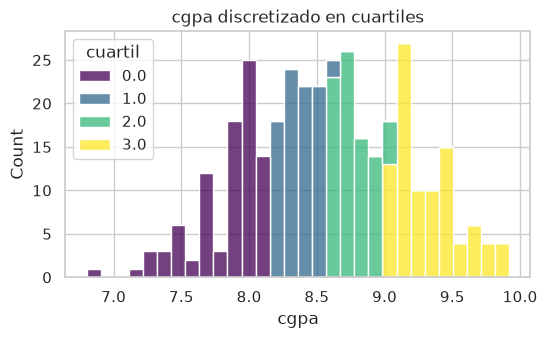

In [11]:
N_BINS = 4
discretizador = KBinsDiscretizer(
    n_bins=N_BINS, encode="ordinal", strategy="quantile", quantile_method="averaged_inverted_cdf"
)
cgpa_train = a_tipos_sklearn(X_train)[["cgpa"]].fillna(X_train["cgpa"].astype(float).median())
cuartiles_cgpa = discretizador.fit_transform(cgpa_train)

print(f"Cortes aprendidos: {discretizador.bin_edges_[0].round(3)}")
comparacion_bins = pd.DataFrame(
    {"cgpa": cgpa_train["cgpa"].to_numpy(), "cuartil": cuartiles_cgpa.ravel()}
)
print(comparacion_bins.groupby("cuartil")["cgpa"].agg(["count", "min", "max"]).round(2).to_string())

_, ax = plt.subplots(figsize=(6, 3.2))
sns.histplot(
    data=comparacion_bins,
    x="cgpa",
    hue="cuartil",
    bins=30,
    multiple="stack",
    palette="viridis",
    ax=ax,
)
ax.set_title("cgpa discretizado en cuartiles")
plt.show()

### 3.3 Transformaciones no lineales (log, sqrt, x²)

El enunciado las propone como opcionales, y aquí la respuesta honesta es que **no
deberían ayudar**: `3-analysis` mostró distribuciones simétricas (|skew| < 0.35). Las
transformaciones de forma sirven para corregir asimetría, y en este dataset no hay
asimetría que corregir.

Pero eso es una hipótesis, no una conclusión. Se construyen igualmente —`log1p(cgpa)`,
`sqrt(sop)`, `gre_score²`— y se miden más abajo junto al resto de variantes.

In [12]:
generador_no_lineales = FunctionTransformer(transformaciones_no_lineales)
ejemplo_no_lineales = generador_no_lineales.fit_transform(a_tipos_sklearn(X_train.head()))

sesgos = a_tipos_sklearn(X_train)[COLS_NUMERICAS].skew().round(3)
print("Asimetría (skew) de las variables originales:")
print(sesgos.to_string())
print("\nColumnas añadidas:", [c for c in ejemplo_no_lineales.columns if c not in X_train.columns])

Asimetría (skew) de las variables originales:
gre_score     -0.042
toefl_score    0.003
sop           -0.259
lor           -0.111
cgpa          -0.064

Columnas añadidas: ['log_cgpa', 'sqrt_sop', 'gre_score_cuadrado']


Ninguna variable supera |skew| = 0.26, muy lejos del umbral habitual de 0.5 a partir del
cual una transformación de forma se plantea siquiera.

## 📏 4. Escalado de atributos

Los predictores viven en escalas muy distintas: `gre_score` entre 290 y 340, `cgpa`
entre 6.8 y 9.9, `sop` y `lor` entre 1 y 5. Sin escalar, cualquier modelo con
regularización (Ridge, Lasso) penaliza más los coeficientes de las variables con números
grandes solo por ser grandes, y los modelos basados en distancias quedan dominados por
`gre_score`.

Las dos opciones estándar:

| Transformador | Qué hace | Cuándo conviene |
|---|---|---|
| `StandardScaler` | media 0, desviación 1 | por defecto; asume distribución aproximadamente simétrica, que es el caso |
| `MinMaxScaler` | lleva todo a [0, 1] | cuando hace falta un rango acotado (redes neuronales, la heurística de `03.3`) |

Se elige **`StandardScaler`**: las distribuciones son simétricas y no hay atípicos
extremos que compriman el resto del rango, que es el punto débil de `MinMaxScaler`.

In [13]:
numericas_imputadas = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(a_tipos_sklearn(X_train)[COLS_NUMERICAS]),
    columns=COLS_NUMERICAS,
)
comparacion_escalado = pd.concat(
    [
        numericas_imputadas.describe().loc[["mean", "std", "min", "max"]].T.add_prefix("original_"),
        pd.DataFrame(StandardScaler().fit_transform(numericas_imputadas), columns=COLS_NUMERICAS)
        .describe()
        .loc[["mean", "std", "min", "max"]]
        .T.add_prefix("standard_"),
        pd.DataFrame(MinMaxScaler().fit_transform(numericas_imputadas), columns=COLS_NUMERICAS)
        .describe()
        .loc[["min", "max"]]
        .T.add_prefix("minmax_"),
    ],
    axis=1,
)
comparacion_escalado.round(3)

,original_mean,original_std,original_min,original_max,standard_mean,standard_std,standard_min,standard_max,minmax_min,minmax_max
gre_score,316.337,11.344,290.0,340.00,-0.0,1.001,-2.325,2.089,0.0,1.0
toefl_score,107.450,6.104,92.0,120.00,0.0,1.001,-2.535,2.059,0.0,1.0
sop,3.371,1.018,1.0,5.00,0.0,1.001,-2.332,1.602,0.0,1.0
lor,3.450,0.905,1.0,5.00,0.0,1.001,-2.711,1.714,0.0,1.0
cgpa,8.582,0.589,6.8,9.92,-0.0,1.001,-3.029,2.275,0.0,1.0


## 🏷️ 5. Encoding

Dos variables no numéricas que codificar, cada una con su propio criterio:

**`university_rating` — categórica ordinal.** Con `OrdinalEncoder` y las categorías
declaradas explícitamente en orden (`1 < 2 < 3 < 4 < 5`), se conserva la información de
orden en una sola columna. Declarar las categorías a mano no es un detalle: fija el
mapeo, de modo que si en producción llegan solo los niveles 2 y 4, se codifican igual que
en entrenamiento.

La alternativa es `OneHotEncoder`, que crea 5 columnas binarias y **descarta el orden**.
Gana flexibilidad (no impone que la distancia entre niveles sea constante) a cambio de
más dimensiones. Se comparan empíricamente más abajo.

**`research` — booleana.** Ya viene como 0/1 tras la conversión de tipos, que es
exactamente lo que produciría un `OneHotEncoder(drop="if_binary")`. No hace falta
transformarla.

In [14]:
rating_train = a_tipos_sklearn(X_train)[COLS_ORDINALES]
rating_imputado = pd.DataFrame(
    SimpleImputer(strategy="most_frequent").fit_transform(rating_train), columns=COLS_ORDINALES
)

CATEGORIAS_RATING = [[1.0, 2.0, 3.0, 4.0, 5.0]]
codificador_ordinal = OrdinalEncoder(categories=CATEGORIAS_RATING).fit(rating_imputado)
codificador_onehot = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(
    rating_imputado
)

print("OrdinalEncoder ->", dict(zip(CATEGORIAS_RATING[0], range(5), strict=True)))
print("OneHotEncoder  ->", list(codificador_onehot.get_feature_names_out()))

ejemplo_encoding = pd.DataFrame({"university_rating": [1.0, 3.0, 5.0]})
print("\nordinal:")
print(codificador_ordinal.transform(ejemplo_encoding).ravel())
print("one-hot:")
print(codificador_onehot.transform(ejemplo_encoding))

OrdinalEncoder -> {1.0: 0, 2.0: 1, 3.0: 2, 4.0: 3, 5.0: 4}
OneHotEncoder  -> ['university_rating_1.0', 'university_rating_2.0', 'university_rating_3.0', 'university_rating_4.0', 'university_rating_5.0']

ordinal:
[0. 2. 4.]
one-hot:
[[1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]]


## 🔗 Ensamblado: el pipeline completo

Con todas las piezas descritas, se ensamblan en una sola estructura. La forma es:

```text
Pipeline
├── tipos          FunctionTransformer  →  nullable de pandas a float64 con np.nan
├── dominio        FunctionTransformer  →  recorta a los rangos documentados
├── derivados      FunctionTransformer  →  indice_academico, sop_lor_media, rating_x_research
└── columnas       ColumnTransformer
    ├── num        SimpleImputer(mediana)  →  StandardScaler
    ├── ord        SimpleImputer(moda)     →  OrdinalEncoder  →  StandardScaler
    └── bool       SimpleImputer(moda)
```

Los tres primeros pasos actúan sobre el DataFrame entero; el `ColumnTransformer` aplica
un tratamiento distinto **a cada grupo de columnas** en paralelo y concatena el
resultado. `set_output(transform="pandas")` hace que el pipeline devuelva un DataFrame
con nombres de columna en vez de un array de numpy, lo que permite auditar la salida.

In [15]:
def construir_preprocesador(
    cols_numericas: list[str],
    cols_ordinales: list[str],
    cols_booleanas: list[str],
    *,
    onehot: bool = False,
    indicador_ausencia: bool = False,
) -> ColumnTransformer:
    """ColumnTransformer con un tratamiento por tipo de columna."""
    tuberia_numerica = Pipeline(
        [("imputar", SimpleImputer(strategy="median")), ("escalar", StandardScaler())]
    )
    if onehot:
        tuberia_ordinal = Pipeline(
            [
                ("imputar", SimpleImputer(strategy="most_frequent")),
                ("codificar", OneHotEncoder(sparse_output=False, handle_unknown="ignore")),
            ]
        )
    else:
        tuberia_ordinal = Pipeline(
            [
                ("imputar", SimpleImputer(strategy="most_frequent")),
                ("codificar", OrdinalEncoder(categories=CATEGORIAS_RATING * len(cols_ordinales))),
                ("escalar", StandardScaler()),
            ]
        )
    return ColumnTransformer(
        [
            ("num", tuberia_numerica, cols_numericas),
            ("ord", tuberia_ordinal, cols_ordinales),
            (
                "bool",
                SimpleImputer(strategy="most_frequent", add_indicator=indicador_ausencia),
                cols_booleanas,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def construir_pipeline(
    columnas: dict[str, list[str]],
    *,
    derivados: bool = False,
    no_lineales: bool = False,
    onehot: bool = False,
    indicador_ausencia: bool = False,
) -> Pipeline:
    """Pipeline de preprocesamiento completo, de datos crudos a matriz de atributos."""
    pasos = [
        ("tipos", FunctionTransformer(a_tipos_sklearn)),
        ("dominio", FunctionTransformer(recortar_a_dominio)),
    ]
    numericas = list(columnas["numericas"])
    booleanas = list(columnas["booleanas"])
    if derivados:
        pasos.append(("derivados", FunctionTransformer(agregar_atributos_derivados)))
        numericas += ["indice_academico", "sop_lor_media"]
        booleanas += ["rating_x_research"]
    if no_lineales:
        pasos.append(("no_lineales", FunctionTransformer(transformaciones_no_lineales)))
        numericas += ["log_cgpa", "sqrt_sop", "gre_score_cuadrado"]
    pasos.append(
        (
            "columnas",
            construir_preprocesador(
                numericas,
                columnas["ordinales"],
                booleanas,
                onehot=onehot,
                indicador_ausencia=indicador_ausencia,
            ),
        )
    )
    return Pipeline(pasos).set_output(transform="pandas")


COLUMNAS_BASE = {
    "numericas": COLS_NUMERICAS,
    "ordinales": COLS_ORDINALES,
    "booleanas": COLS_BOOLEANAS,
}

preprocesador = construir_pipeline(COLUMNAS_BASE)
preprocesador

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tipos', ...), ('dominio', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function a_t...x7f3738108cc0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary 

In [16]:
X_train_preparado = preprocesador.fit_transform(X_train)
X_test_preparado = preprocesador.transform(X_test)

print(f"X_train: {X_train.shape} -> {X_train_preparado.shape}")
print(f"X_test : {X_test.shape} -> {X_test_preparado.shape}")
print(f"Nulos restantes: {int(X_train_preparado.isna().sum().sum())}")
X_train_preparado.head().round(3)

X_train: (353, 7) -> (353, 7)
X_test : (118, 7) -> (118, 7)
Nulos restantes: 0


,gre_score,toefl_score,sop,lor,cgpa,university_rating,research
94,-1.177,-1.386,-1.349,-1.052,-1.567,-0.095,0.0
287,0.676,1.075,1.602,1.161,0.847,1.629,1.0
369,-1.354,-1.550,-1.349,-0.498,-0.938,-1.820,1.0
324,-0.118,-0.566,-0.365,-1.052,-0.428,-0.095,0.0
314,-1.001,-0.402,-0.365,0.608,-0.768,-0.958,0.0


In [17]:
resumen_salida = X_train_preparado.describe().loc[["mean", "std", "min", "max"]].T.round(3)
print("Las numéricas quedan centradas en 0 con desviación 1; research se queda en 0/1:")
resumen_salida

Las numéricas quedan centradas en 0 con desviación 1; research se queda en 0/1:


,mean,std,min,max
gre_score,-0.000,1.001,-2.325,2.089
toefl_score,0.000,1.001,-2.535,2.059
sop,0.000,1.001,-2.332,1.602
lor,0.000,1.001,-2.711,1.714
cgpa,-0.000,1.001,-3.029,2.275
university_rating,-0.000,1.001,-1.820,1.629
research,0.555,0.498,0.000,1.000


La salida es un DataFrame con las 7 columnas escaladas y sin nulos. `research` conserva
sus valores 0/1 (no se escala: una binaria estandarizada pierde legibilidad sin ganar
nada) y el resto tiene media 0 y desviación 1 **en train**. En test, la media no será
exactamente 0 — y eso es correcto: se aplican los parámetros de train, no se recalculan.

## 🧪 ¿Qué variante conviene? Comparación con evidencia

Hasta aquí se han construido todas las piezas que pide el enunciado. La pregunta que
queda es **cuáles conviene activar**, y esa no se responde con criterio estético.

Se comparan seis variantes con validación cruzada repetida (`RepeatedKFold`, 5 pliegues
x 5 repeticiones) sobre el conjunto de **entrenamiento**, usando una `Ridge` como modelo
de referencia. Ridge es la elección adecuada aquí: es sensible al escalado y a la
multicolinealidad, así que amplifica las diferencias entre variantes de preprocesamiento
en vez de taparlas.

El conjunto de prueba **no participa** en esta comparación: elegir la variante mirando el
test sería otra forma de fuga de datos.

In [18]:
VARIANTES = {
    "1. base (7 atributos)": construir_pipeline(COLUMNAS_BASE),
    "2. base + one-hot rating": construir_pipeline(COLUMNAS_BASE, onehot=True),
    "3. base + atributos derivados": construir_pipeline(COLUMNAS_BASE, derivados=True),
    "4. base + log/sqrt/cuadrado": construir_pipeline(COLUMNAS_BASE, no_lineales=True),
    "5. sin toefl_score": construir_pipeline(
        {**COLUMNAS_BASE, "numericas": [c for c in COLS_NUMERICAS if c != "toefl_score"]}
    ),
    "6. minimo (cgpa, lor, rating, research)": construir_pipeline(
        {**COLUMNAS_BASE, "numericas": ["cgpa", "lor"]}
    ),
    "7. base + indicador de ausencia": construir_pipeline(COLUMNAS_BASE, indicador_ausencia=True),
}

validacion = RepeatedKFold(n_splits=5, n_repeats=5, random_state=SEMILLA)
filas_comparacion = []
for nombre, pipeline_variante in VARIANTES.items():
    modelo = Pipeline([("preparacion", pipeline_variante), ("modelo", Ridge(alpha=1.0))])
    errores = -cross_val_score(
        modelo, X_train, y_train, cv=validacion, scoring="neg_mean_absolute_error"
    )
    filas_comparacion.append(
        {"variante": nombre, "MAE_cv": errores.mean(), "desv_est": errores.std()}
    )

comparacion = pd.DataFrame(filas_comparacion).set_index("variante").sort_values("MAE_cv")
comparacion.round(4)

,MAE_cv,desv_est
variante,,
4. base + log/sqrt/cuadrado,0.0467,0.0047
1. base (7 atributos),0.0468,0.0047
3. base + atributos derivados,0.0468,0.0046
7. base + indicador de ausencia,0.0469,0.0047
2. base + one-hot rating,0.0474,0.0043
5. sin toefl_score,0.0475,0.0052
"6. minimo (cgpa, lor, rating, research)",0.0490,0.0050


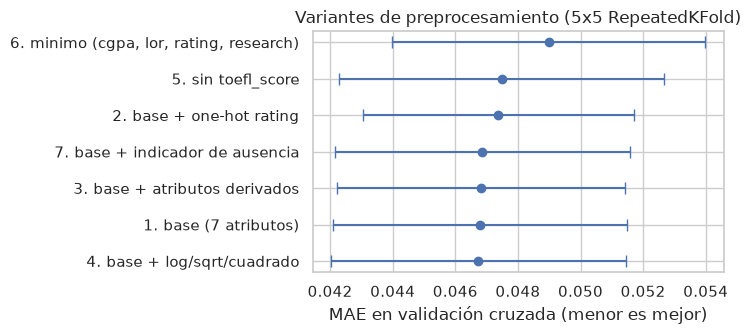

In [19]:
_, ax = plt.subplots(figsize=(7.5, 3.5))
ordenadas = comparacion.sort_values("MAE_cv")
ax.errorbar(ordenadas["MAE_cv"], ordenadas.index, xerr=ordenadas["desv_est"], fmt="o", capsize=4)
ax.set_xlabel("MAE en validación cruzada (menor es mejor)")
ax.set_title("Variantes de preprocesamiento (5x5 RepeatedKFold)")
plt.tight_layout()
plt.show()

**Todas las variantes caben dentro de una desviación estándar unas de otras.** La
diferencia entre la mejor (0.0467) y la peor (0.0490) es de 0.0023, frente a una
desviación de ±0.005 entre pliegues: **no hay diferencia real**. La variante que encabeza
la tabla lo hace por 0.0001 sobre la base — eso no es una ventaja, es ruido.

Eso es un resultado, no un fracaso, y encaja exactamente con lo que mostró
`3-analysis`: las siete variables giran alrededor de un mismo eje latente de "calidad del
expediente". Cuando toda la información está en un factor común:

- **Los atributos derivados no añaden nada** (0.0468 vs. 0.0468): el `indice_academico`
  es un resumen de variables que el modelo lineal ya podía combinar por su cuenta.
- **Las transformaciones no lineales tampoco** (0.0467): la diferencia con la base está
  en el cuarto decimal, muy por debajo del ruido entre pliegues. Como se anticipó, no hay
  asimetría que corregir.
- **El indicador de ausencia no aporta** (0.0469): cierra la duda que dejó abierta el
  p = 0.012 de `research` en el diagnóstico de nulos.
- **La discretización de `cgpa` no se incluye** entre las variantes ganadoras por la
  misma razón: convertir una variable continua en 4 niveles solo pierde resolución
  cuando la relación con el target ya es lineal (r = 0.88).
- **One-hot pierde un poco** frente a ordinal (0.0474 vs. 0.0468): descartar el orden de
  una escala que sí lo tiene cuesta información.
- **Quitar `toefl_score` no penaliza** (0.0475): confirma que era redundante. La versión
  `minimo` sí empeora de forma visible (0.0490) — recortar a 4 atributos ya pierde señal
  y además genera filas duplicadas.

**Decisión: se elige la variante 1, la base con codificación ordinal.** Es la más simple
de las que empatan en el primer puesto, y en igualdad de resultados la simplicidad gana:
menos columnas que mantener, menos cosas que puedan romperse en producción, y un modelo
que se puede explicar.

La variante 5 (`sin_toefl_score`) queda documentada como alternativa preferible si en
`6-interpretation` se necesita interpretar coeficientes, porque baja el VIF del bloque
académico.

## ✅ Validación de extremo a extremo

El pipeline elegido se entrena sobre *train* y se evalúa una sola vez sobre *test*. La
referencia es el **piso heurístico de `03.3`**: la regla manual recalibrada, medida sobre
esta misma partición para que la comparación sea justa.

In [20]:
modelo_completo = Pipeline([("preparacion", preprocesador), ("modelo", Ridge(alpha=1.0))])
modelo_completo.fit(X_train, y_train)
prediccion_test = modelo_completo.predict(X_test)

# piso de referencia: heuristica de 03.3 recalibrada sobre esta misma particion
X_normalizado = a_tipos_sklearn(X)
heuristica = pd.DataFrame(
    {
        "gre_score": (X_normalizado["gre_score"] - 260) / 80,
        "toefl_score": X_normalizado["toefl_score"] / 120,
        "university_rating": (X_normalizado["university_rating"] - 1) / 4,
        "sop": (X_normalizado["sop"] - 1) / 4,
        "lor": (X_normalizado["lor"] - 1) / 4,
        "cgpa": X_normalizado["cgpa"] / 10,
        "research": X_normalizado["research"],
    }
).mean(axis=1)
diseno_train = np.c_[np.ones(len(X_train)), heuristica.loc[X_train.index]]
coeficientes, *_ = np.linalg.lstsq(diseno_train, y_train.to_numpy(), rcond=None)
prediccion_heuristica = coeficientes[0] + coeficientes[1] * heuristica.loc[X_test.index]

resultados = pd.DataFrame(
    {
        "MAE": [
            mean_absolute_error(y_test, np.full(len(y_test), y_train.mean())),
            mean_absolute_error(y_test, prediccion_heuristica),
            mean_absolute_error(y_test, prediccion_test),
        ],
        "R2": [
            r2_score(y_test, np.full(len(y_test), y_train.mean())),
            r2_score(y_test, prediccion_heuristica),
            r2_score(y_test, prediccion_test),
        ],
    },
    index=["baseline: media del target", "piso: heuristica de 03.3", "pipeline + Ridge"],
)
resultados.round(4)

,MAE,R2
baseline: media del target,0.1191,-0.0017
piso: heuristica de 03.3,0.0643,0.6667
pipeline + Ridge,0.0485,0.7934


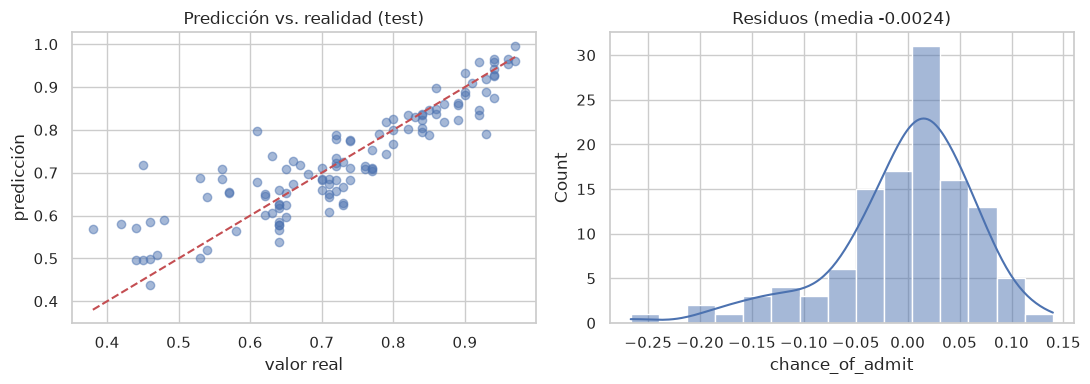

Residuo maximo: 0.267


In [21]:
_, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, prediccion_test, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_xlabel("valor real")
axes[0].set_ylabel("predicción")
axes[0].set_title("Predicción vs. realidad (test)")

residuos = y_test - prediccion_test
sns.histplot(residuos, kde=True, ax=axes[1])
axes[1].set_title(f"Residuos (media {residuos.mean():.4f})")
plt.tight_layout()
plt.show()

print(f"Residuo maximo: {residuos.abs().max():.3f}")

El pipeline con una `Ridge` sin ajustar alcanza **MAE 0.0485** y **R² 0.79** en el
conjunto de prueba, frente a 0.0643 de la heurística de `03.3` (25 % mejor) y 0.1191 del
baseline trivial.
Supera el criterio de aceptación fijado al final de `3-analysis` (MAE ≤ 0.063), lo que
confirma que **el preprocesamiento no está estropeando la señal**.

Un detalle en los residuos: están centrados en cero y son aproximadamente simétricos,
pero los errores más grandes se concentran en los aspirantes con probabilidad baja — el
extremo donde hay menos datos. Es un aviso para `5-models`, no un problema del
preprocesamiento.

**Importante:** esto no es la etapa de modelado. La `Ridge` está aquí como instrumento
de medición del pipeline, con sus parámetros por defecto y sin ajuste de
hiperparámetros. Elegir y afinar el modelo es `5-models`.

## 💾 Guardar el pipeline y la matriz de atributos

Se guardan dos cosas distintas, y la primera es la que importa:

1. **El pipeline ajustado** (`joblib`), en `data/06_models/`. Contiene los parámetros
   aprendidos —las medianas, las medias y desviaciones del escalado, el mapeo del
   encoder— y es lo que se carga en `7-deploy` para transformar un aspirante nuevo
   exactamente igual que en entrenamiento.
2. **Las matrices ya transformadas** (`.parquet`), en `data/05_model_input/`, para que
   `5-models` arranque sin repetir el trabajo.

In [22]:
ARCHIVO_PIPELINE = DIR_MODELOS / "pipeline_preprocesamiento.joblib"
joblib.dump(modelo_completo.named_steps["preparacion"], ARCHIVO_PIPELINE)

for nombre, datos in [
    ("X_train", X_train_preparado),
    ("X_test", X_test_preparado),
    ("y_train", y_train.to_frame()),
    ("y_test", y_test.to_frame()),
]:
    ruta = DIR_MODEL_INPUT / f"{nombre}.parquet"
    datos.reset_index(drop=True).to_parquet(ruta, index=False)
    print(f"{nombre:8s} {datos.shape!s:12s} -> {ruta.relative_to(RAIZ)}")

print(
    f"\npipeline -> {ARCHIVO_PIPELINE.relative_to(RAIZ)} ({ARCHIVO_PIPELINE.stat().st_size / 1024:.1f} KB)"
)

X_train  (353, 7)     -> data/05_model_input/X_train.parquet
X_test   (118, 7)     -> data/05_model_input/X_test.parquet
y_train  (353, 1)     -> data/05_model_input/y_train.parquet
y_test   (118, 1)     -> data/05_model_input/y_test.parquet

pipeline -> data/06_models/pipeline_preprocesamiento.joblib (5.9 KB)


In [23]:
# el artefacto solo sirve si se puede volver a cargar y produce lo mismo
pipeline_recargado = joblib.load(ARCHIVO_PIPELINE)
salida_recargada = pipeline_recargado.transform(X_test)

if not np.allclose(salida_recargada.to_numpy(), X_test_preparado.to_numpy()):
    raise ValueError("El pipeline recargado no reproduce la misma salida")

aspirante_nuevo = pd.DataFrame(
    [
        {
            "gre_score": 325,
            "toefl_score": 113,
            "university_rating": 4,
            "sop": 4.5,
            "lor": None,
            "cgpa": 9.1,
            "research": True,
        }
    ]
)
print("El pipeline recargado reproduce la misma salida.")
print("\nUn aspirante nuevo, con un dato faltante, transformado de punta a punta:")
pipeline_recargado.transform(aspirante_nuevo).round(3)

El pipeline recargado reproduce la misma salida.

Un aspirante nuevo, con un dato faltante, transformado de punta a punta:


,gre_score,toefl_score,sop,lor,cgpa,university_rating,research
0,0.765,0.91,1.11,0.055,0.881,0.767,1.0


La última celda es la prueba de que esto sirve para producción: un aspirante nuevo, **con
un valor faltante en `lor`**, entra como datos crudos y sale como una fila lista para el
modelo. El pipeline imputa con la mediana aprendida en entrenamiento, recorta al dominio,
codifica y escala, sin que haya que recordar ni repetir ninguno de esos pasos a mano.

## 📊 Analysis of Results and Conclusions

**Lo que se construyó:** un `Pipeline` de scikit-learn que va de los datos crudos a una
matriz de atributos lista para entrenar, con los cinco bloques que pide el enunciado.

| Etapa | Implementación | Decisión y por qué |
|---|---|---|
| Limpieza: duplicados | fuera del pipeline (verificación) | un transformador no puede eliminar filas sin desalinear `X` e `y`; ya se hizo en `2-exploration` |
| Limpieza: atípicos | `FunctionTransformer(recortar_a_dominio)` | los 4 atípicos se **conservan** (son cola real, no errores); el recorte protege la inferencia |
| Limpieza: faltantes | `SimpleImputer` mediana / moda | la señal aparente en `research` (p = 0.012) no sobrevive a Bonferroni ni replica en el dataset completo, y el indicador de ausencia no mejora el MAE |
| Selección de atributos | 3 conjuntos comparados | se conservan los 7: recortar no mejora y genera duplicados |
| Ingeniería de atributos | `FunctionTransformer` + `KBinsDiscretizer` | construidos y medidos; **no se activan** porque no mejoran |
| Escalado | `StandardScaler` | distribuciones simétricas sin atípicos extremos |
| Encoding | `OrdinalEncoder` con orden explícito | conserva el orden de la escala 1-5; one-hot resultó peor |

**El resultado principal es negativo, y conviene decirlo claro:** ninguna de las
transformaciones sofisticadas —atributos derivados, discretización, log/sqrt/cuadrado,
one-hot, indicador de ausencia— mejora sobre el pipeline base. Las siete variantes
empatan dentro del ruido de la validación cruzada (0.0467 a 0.0490, con ±0.005 de
desviación entre pliegues).

No es un fallo del diseño: es la consecuencia directa de lo que encontró `3-analysis`.
Cuando siete variables miden un mismo rasgo latente y su relación con el target ya es
lineal, no queda estructura escondida que la ingeniería de atributos pueda sacar a la
luz. El valor de haberlas construido está en **haberlo medido en vez de suponerlo**, y en
dejar el andamiaje listo por si entran datos nuevos (un ranking real de universidad, el
área de estudio) donde sí haya algo que extraer.

**Verificación end-to-end:** MAE 0.0485 y R² 0.79 en test con una `Ridge` por defecto,
contra 0.0643 del piso heurístico y 0.1191 del baseline. El preprocesamiento conserva la
señal.

## 💡 Proposals and Ideas

- **`5-models` puede arrancar directo** desde `data/05_model_input/`, o mejor, montar el
  `Pipeline` completo (preprocesamiento + modelo) y hacer la búsqueda de
  hiperparámetros sobre él con `GridSearchCV`: así el preprocesamiento se reajusta dentro
  de cada pliegue y no se filtra información entre particiones.
- **Reevaluar la ingeniería de atributos con modelos no lineales.** Todo se comparó con
  `Ridge`. Un modelo de árboles no necesita `rating_x_research` porque captura la
  interacción solo, pero sí puede aprovechar la discretización de forma distinta.
- **Convertir la selección de atributos en un paso del pipeline** (`SelectKBest`,
  `SequentialFeatureSelector`) para que se decida dentro de la validación cruzada, en vez
  de comparar variantes a mano como aquí.
- **Mover el pipeline a `src/pipelines/feature_pipeline`** cuando se estabilice: las
  funciones de transformación ya están en `src/data/transformaciones.py` y con test, así
  que el paso siguiente es que el notebook solo lo invoque.
- **Vigilar la deriva de datos:** las medianas y escalas guardadas en el artefacto
  reflejan la muestra actual (aspirantes con `cgpa` medio 8.59). Si el perfil de los
  usuarios cambia, hay que reajustar el pipeline, no solo el modelo.

## 📖 References

- Preprocesamiento en scikit-learn: <https://scikit-learn.org/stable/modules/preprocessing.html>
- Pipelines y `ColumnTransformer`: <https://scikit-learn.org/stable/modules/compose.html>
- Feature engineering, Jose R. Zapata:
  <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/4-feat_eng/>
- `KBinsDiscretizer`:
  <https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.KBinsDiscretizer.html>
- Funciones de transformación de este proyecto: `src/data/transformaciones.py`